[run] region=MCX, class=Ex
  cells=14048, genes_present=16, missing=[]
  subtypes_present=14 / 14
[run] region=PFC, class=Ex
  cells=38255, genes_present=16, missing=[]
  subtypes_present=14 / 14
[run] region=MCX, class=In
  cells=5143, genes_present=16, missing=[]
  subtypes_present=15 / 15
[run] region=PFC, class=In
  cells=13610, genes_present=16, missing=[]
  subtypes_present=15 / 15
[write] /root/autodl-tmp/jupyter/vulnerable_neurons/09_scDRS_TXD_integrated/results/ALS_RISK_gene_enrichment_merged/Ex_In_combined_PN_subtype_gene_enrichment_heatmap.png
[write] /root/autodl-tmp/jupyter/vulnerable_neurons/09_scDRS_TXD_integrated/results/ALS_RISK_gene_enrichment_merged/Ex_In_combined_PN_subtype_gene_enrichment_heatmap.pdf


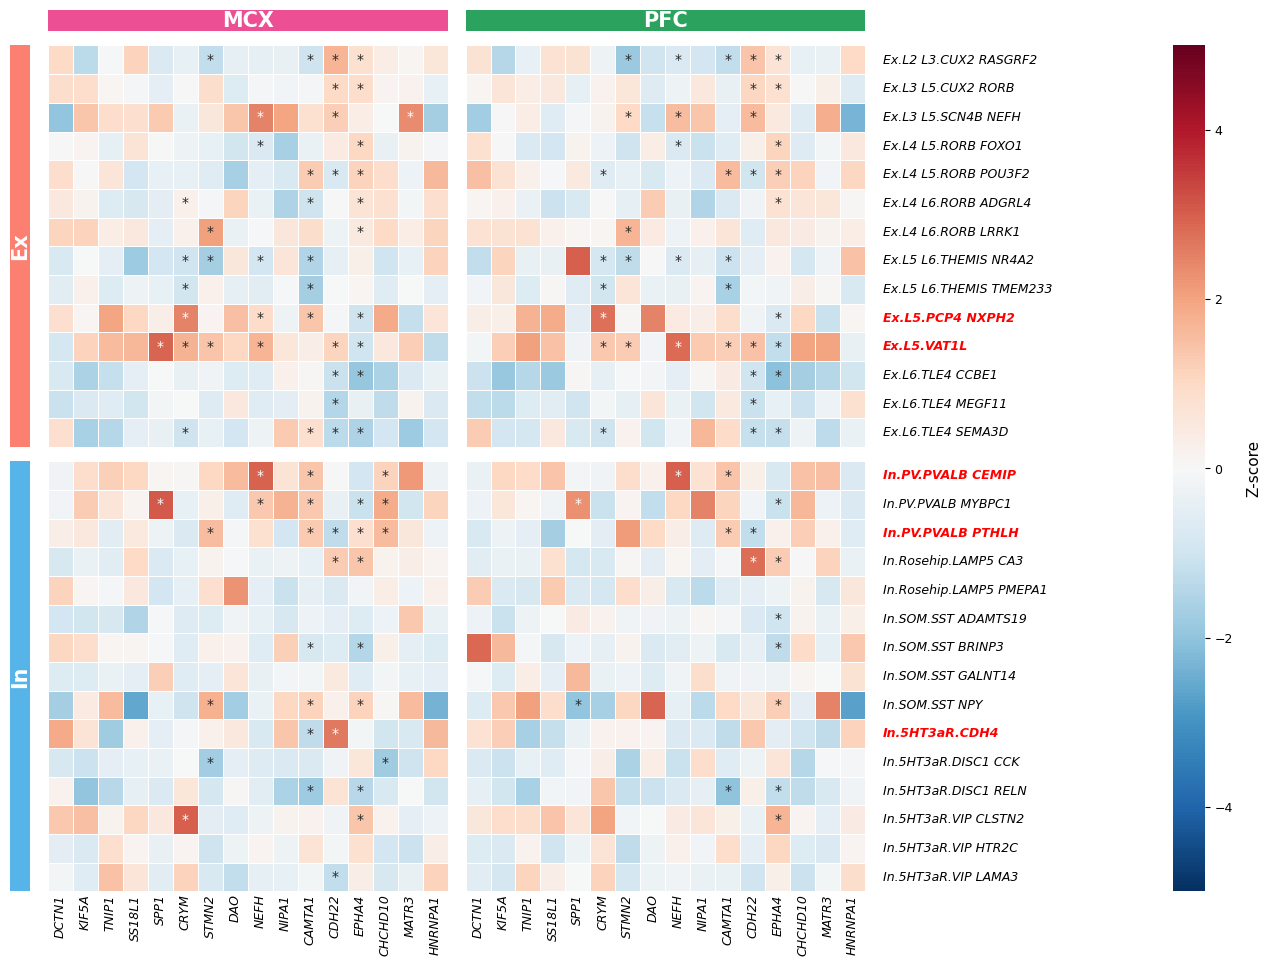

[done]


In [12]:
#!/usr/bin/env python

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import fdrcorrection
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings("ignore")


# =========================
# Parameters
# =========================

paths = {
    "MCX": "/root/autodl-tmp/jupyter/prepare/harmony/SALS_MCX_control_concat_QC_harmony.h5ad",
    "PFC": "/root/autodl-tmp/jupyter/prepare/harmony/SALS_PFC_control_concat_QC_harmony.h5ad",
}

outdir = Path("/root/autodl-tmp/jupyter/vulnerable_neurons/09_scDRS_TXD_integrated/results/ALS_RISK_gene_enrichment_merged")
outdir.mkdir(parents=True, exist_ok=True)

cell_type_col = "Org_celltype"
group_col = "Group"
pn_label = "PN"

n_iters = 100
n_cells_sample = 150
random_seed = 123
fdr_cut = 0.001

merge_map = {
    "In.5HT3aR.CDH4_CCK": "In.5HT3aR.CDH4",
    "In.5HT3aR.CDH4_SCGN": "In.5HT3aR.CDH4",
    "Ex.L5.VAT1L_EYA4": "Ex.L5.VAT1L",
    "Ex.L5.VAT1L_THSD4": "Ex.L5.VAT1L",
}

target_genes = [
    "DCTN1", "KIF5A", "TNIP1", "SS18L1", "SPP1", "CRYM", "STMN2", "DAO",
    "NEFH", "NIPA1", "CAMTA1", "CDH22", "EPHA4", "CHCHD10", "MATR3",
    "HNRNPA1",
]

ex_subtypes = [
    "Ex.L2_L3.CUX2_RASGRF2",
    "Ex.L3_L5.CUX2_RORB",
    "Ex.L3_L5.SCN4B_NEFH",
    "Ex.L4_L5.RORB_FOXO1",
    "Ex.L4_L5.RORB_POU3F2",
    "Ex.L4_L6.RORB_ADGRL4",
    "Ex.L4_L6.RORB_LRRK1",
    "Ex.L5_L6.THEMIS_NR4A2",
    "Ex.L5_L6.THEMIS_TMEM233",
    "Ex.L5.PCP4_NXPH2",
    "Ex.L5.VAT1L",
    "Ex.L6.TLE4_CCBE1",
    "Ex.L6.TLE4_MEGF11",
    "Ex.L6.TLE4_SEMA3D",
]

in_subtypes = [
    "In.PV.PVALB_CEMIP",
    "In.PV.PVALB_MYBPC1",
    "In.PV.PVALB_PTHLH",
    "In.Rosehip.LAMP5_CA3",
    "In.Rosehip.LAMP5_PMEPA1",
    "In.SOM.SST_ADAMTS19",
    "In.SOM.SST_BRINP3",
    "In.SOM.SST_GALNT14",
    "In.SOM.SST_NPY",
    "In.5HT3aR.CDH4",
    "In.5HT3aR.DISC1_CCK",
    "In.5HT3aR.DISC1_RELN",
    "In.5HT3aR.VIP_CLSTN2",
    "In.5HT3aR.VIP_HTR2C",
    "In.5HT3aR.VIP_LAMA3",
]

highlight_subtypes = {
    "Ex.L5.PCP4_NXPH2",
    "Ex.L5.VAT1L",
    "In.PV.PVALB_CEMIP",
    "In.PV.PVALB_PTHLH",
    "In.5HT3aR.CDH4",
}


# =========================
# Enrichment
# =========================

def get_expression_adata(adata):
    return adata.raw.to_adata() if adata.raw is not None else adata


def sample_rows(df, n, rng):
    replace = df.shape[0] < n
    return df.sample(
        n=n,
        replace=replace,
        random_state=int(rng.integers(1, 1_000_000_000)),
    )


def analyze_region_class(adata_path, region_name, class_name, subtypes, genes):
    print(f"[run] region={region_name}, class={class_name}")

    adata = sc.read_h5ad(adata_path)
    adata = get_expression_adata(adata)

    adata.obs["merged_subtype"] = (
        adata.obs[cell_type_col]
        .astype(str)
        .replace(merge_map)
    )

    mask = (
        (adata.obs[group_col].astype(str) == pn_label)
        & (adata.obs["merged_subtype"].astype(str).isin(subtypes))
    )
    adata_pn = adata[mask].copy()

    genes_present = [g for g in genes if g in adata_pn.var_names]
    missing_genes = [g for g in genes if g not in adata_pn.var_names]

    print(
        f"  cells={adata_pn.n_obs}, "
        f"genes_present={len(genes_present)}, "
        f"missing={missing_genes}"
    )

    if len(genes_present) == 0:
        raise ValueError(f"No target genes found for {region_name} {class_name}")

    X = adata_pn[:, genes_present].X
    if hasattr(X, "toarray"):
        X = X.toarray()

    df = pd.DataFrame(X, index=adata_pn.obs_names, columns=genes_present)
    df["Subtype"] = adata_pn.obs["merged_subtype"].astype(str).values

    present_subtypes = [s for s in subtypes if s in set(df["Subtype"])]
    print(f"  subtypes_present={len(present_subtypes)} / {len(subtypes)}")

    rng = np.random.default_rng(random_seed)
    trial_tables = []

    for trial in range(n_iters):
        sampled_parts = []

        for subtype in present_subtypes:
            cells = df[df["Subtype"] == subtype]
            if cells.shape[0] == 0:
                continue
            sampled_parts.append(sample_rows(cells, n_cells_sample, rng))

        df_trial = pd.concat(sampled_parts, axis=0)
        records = []

        for subtype in present_subtypes:
            target = df_trial[df_trial["Subtype"] == subtype]
            background = df_trial[df_trial["Subtype"] != subtype]

            for gene in genes_present:
                x = target[gene].to_numpy()
                y = background[gene].to_numpy()

                lfc = np.nanmean(x) - np.nanmean(y)

                try:
                    _, p = mannwhitneyu(x, y, alternative="two-sided")
                except ValueError:
                    p = 1.0

                records.append({
                    "trial": trial,
                    "region": region_name,
                    "class": class_name,
                    "subtype": subtype,
                    "gene": gene,
                    "lfc": lfc,
                    "p_value": p,
                })

        trial_df = pd.DataFrame(records)
        _, fdr = fdrcorrection(trial_df["p_value"].to_numpy())
        trial_df["p_fdr"] = fdr
        trial_tables.append(trial_df)

    all_trials = pd.concat(trial_tables, axis=0)

    result = (
        all_trials
        .groupby(["region", "class", "subtype", "gene"], as_index=False)
        .agg(
            mean_lfc=("lfc", "mean"),
            mean_p_value=("p_value", "mean"),
            mean_fdr=("p_fdr", "mean"),
        )
    )

    result["zscore"] = np.nan

    for gene in genes_present:
        idx = result["gene"] == gene
        vals = result.loc[idx, "mean_lfc"].to_numpy()

        sd = np.nanstd(vals, ddof=1)
        mu = np.nanmean(vals)

        if sd == 0 or np.isnan(sd):
            result.loc[idx, "zscore"] = 0
        else:
            result.loc[idx, "zscore"] = (vals - mu) / sd

    return result


# =========================
# Plot
# =========================

def draw_facet_strip(ax, label, color, rotation=0, fontsize=15):
    ax.set_facecolor(color)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.text(
        0.5,
        0.5,
        label,
        ha="center",
        va="center",
        rotation=rotation,
        fontsize=fontsize,
        fontweight="bold",
        color="white",
        transform=ax.transAxes,
    )


def plot_enrichment(
    all_result,
    ex_subtypes,
    in_subtypes,
    genes,
    out_prefix,
    fdr_cut=0.001,
    show=True,
):
    class_map = {"Ex": ex_subtypes, "In": in_subtypes}
    class_colors = {"Ex": "#FB8072", "In": "#56B4E9"}
    region_colors = {"MCX": "#ec4f93", "PFC": "#2ca25f"}

    row_heights = [len(ex_subtypes), len(in_subtypes)]

    fig = plt.figure(
        figsize=(
            max(13.5, len(genes) * 0.68),
            max(10.8, (len(ex_subtypes) + len(in_subtypes)) * 0.40),
        )
    )

    gs = gridspec.GridSpec(
        nrows=3,
        ncols=5,
        width_ratios=[0.05, 1.0, 1.0, 0.68, 0.08],
        height_ratios=[0.75, row_heights[0], row_heights[1]],
        wspace=0.08,
        hspace=0.05,
        figure=fig,
    )

    cmap = sns.color_palette("RdBu_r", as_cmap=True)
    cmap.set_bad(color="lightgray")

    cbar_ax = fig.add_subplot(gs[1:, 4])

    empty_ax = fig.add_subplot(gs[0, 0])
    empty_ax.axis("off")

    for col_idx, region in enumerate(["MCX", "PFC"]):
        region_ax = fig.add_subplot(gs[0, col_idx + 1])
        draw_facet_strip(region_ax, region, region_colors[region])

    for cell in [(0, 3), (0, 4)]:
        ax_empty = fig.add_subplot(gs[cell])
        ax_empty.axis("off")

    for row_idx, class_name in enumerate(["Ex", "In"], start=1):
        subtypes = class_map[class_name]

        class_ax = fig.add_subplot(gs[row_idx, 0])
        draw_facet_strip(
            class_ax,
            class_name,
            class_colors[class_name],
            rotation=90,
            fontsize=15,
        )

        label_ax = fig.add_subplot(gs[row_idx, 3])
        label_ax.set_xlim(0, 1)
        label_ax.set_ylim(len(subtypes), 0)
        label_ax.axis("off")

        for i, subtype in enumerate(subtypes):
            is_highlight = subtype in highlight_subtypes

            label_ax.text(
                0,
                i + 0.5,
                subtype.replace("_", " "),
                ha="left",
                va="center",
                fontsize=9,
                fontstyle="italic",
                fontweight="bold" if is_highlight else "normal",
                color="red" if is_highlight else "black",
            )


        for col_idx, region in enumerate(["MCX", "PFC"]):
            ax = fig.add_subplot(gs[row_idx, col_idx + 1])

            sub = all_result[
                (all_result["class"] == class_name)
                & (all_result["region"] == region)
            ].copy()

            z = sub.pivot(index="subtype", columns="gene", values="zscore")
            f = sub.pivot(index="subtype", columns="gene", values="mean_fdr")

            z = z.reindex(index=subtypes, columns=genes)
            f = f.reindex(index=subtypes, columns=genes)

            annot = f.applymap(
                lambda x: "*" if pd.notna(x) and x < fdr_cut else ""
            )

            sns.heatmap(
                z,
                ax=ax,
                cmap=cmap,
                vmin=-5,
                vmax=5,
                center=0,
                linewidths=0.4,
                linecolor="white",
                annot=annot,
                fmt="",
                cbar=(row_idx == 1 and col_idx == 1),
                cbar_ax=cbar_ax if (row_idx == 1 and col_idx == 1) else None,
                cbar_kws={"label": "Z-score"},
                xticklabels=True,
                yticklabels=False,
            )

            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.tick_params(axis="y", length=0)

            ax.xaxis.tick_bottom()

            if row_idx == 2:
                ax.set_xticklabels(
                    ax.get_xticklabels(),
                    rotation=90,
                    fontsize=9,
                    fontstyle="italic",
                )
                ax.tick_params(axis="x", length=0, pad=2)
            else:
                ax.set_xticklabels([])
                ax.tick_params(axis="x", length=0)

    cbar_ax.yaxis.set_label_position("right")
    cbar_ax.yaxis.tick_right()
    cbar_ax.tick_params(labelsize=9)
    cbar_ax.set_ylabel("Z-score", fontsize=11, labelpad=10)

    fig.suptitle(
        "",
        fontsize=18,
        fontweight="bold",
        y=0.975,
    )

    fig.subplots_adjust(
        left=0.055,
        right=0.94,
        top=0.88,
        bottom=0.12,
    )

    png = out_prefix.with_suffix(".png")
    pdf = out_prefix.with_suffix(".pdf")

    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")

    print(f"[write] {png}")
    print(f"[write] {pdf}")

    if show:
        plt.show()
    else:
        plt.close(fig)


# =========================
# Run
# =========================

all_results = []

for class_name, subtypes in {"Ex": ex_subtypes, "In": in_subtypes}.items():
    class_results = []

    for region_name, adata_path in paths.items():
        res = analyze_region_class(
            adata_path=adata_path,
            region_name=region_name,
            class_name=class_name,
            subtypes=subtypes,
            genes=target_genes,
        )
        class_results.append(res)

    class_result = pd.concat(class_results, axis=0)
    class_result.to_csv(
        outdir / f"{class_name}_PN_subtype_gene_enrichment.tsv",
        sep="\t",
        index=False,
    )

    all_results.append(class_result)

all_result = pd.concat(all_results, axis=0)
all_result.to_csv(
    outdir / "Ex_In_PN_subtype_gene_enrichment_all.tsv",
    sep="\t",
    index=False,
)

common_genes = [
    g for g in target_genes
    if g in set(all_result[all_result["region"] == "MCX"]["gene"])
    and g in set(all_result[all_result["region"] == "PFC"]["gene"])
]

plot_enrichment(
    all_result=all_result,
    ex_subtypes=ex_subtypes,
    in_subtypes=in_subtypes,
    genes=common_genes,
    out_prefix=outdir / "Ex_In_combined_PN_subtype_gene_enrichment_heatmap",
    fdr_cut=fdr_cut,
    show=True,
)

print("[done]")


[run] region=MCX, class=Ex
  cells=14048, genes_present=16, missing=[]
  subtypes_present=14 / 14
[run] region=PFC, class=Ex
  cells=38255, genes_present=16, missing=[]
  subtypes_present=14 / 14
[run] region=MCX, class=In
  cells=5143, genes_present=16, missing=[]
  subtypes_present=15 / 15
[run] region=PFC, class=In
  cells=13610, genes_present=16, missing=[]
  subtypes_present=15 / 15
[write] /root/autodl-tmp/jupyter/vulnerable_neurons/09_scDRS_TXD_integrated/results/ALS_RISK_gene_enrichment_merged/Ex_In_combined_PN_subtype_gene_enrichment_heatmap_small_colorbar_height.png
[write] /root/autodl-tmp/jupyter/vulnerable_neurons/09_scDRS_TXD_integrated/results/ALS_RISK_gene_enrichment_merged/Ex_In_combined_PN_subtype_gene_enrichment_heatmap_small_colorbar_height.pdf


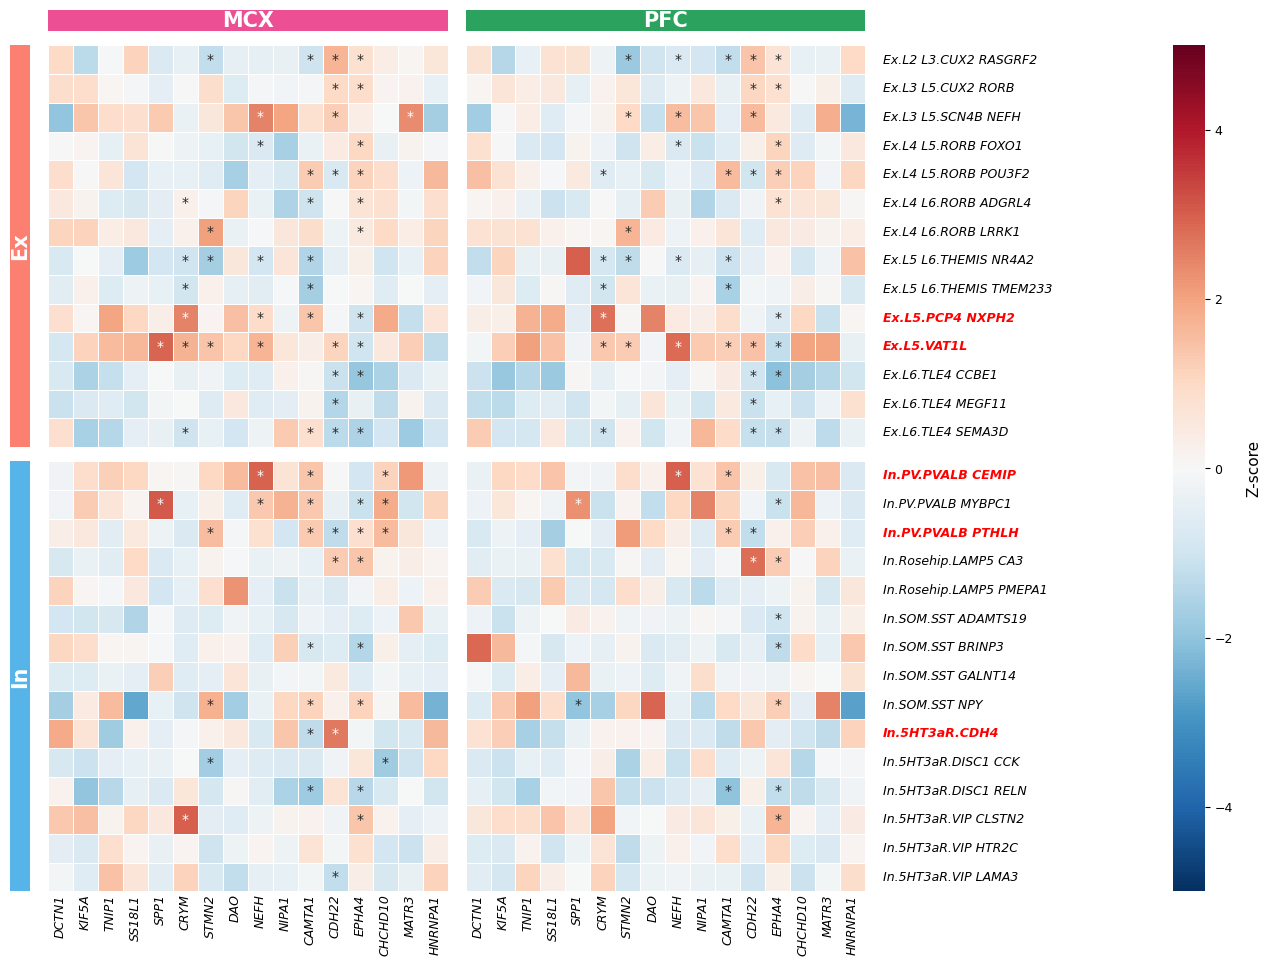

[done]


In [15]:
#!/usr/bin/env python

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import fdrcorrection
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings("ignore")


# =========================
# Parameters
# =========================

paths = {
    "MCX": "/root/autodl-tmp/jupyter/prepare/harmony/SALS_MCX_control_concat_QC_harmony.h5ad",
    "PFC": "/root/autodl-tmp/jupyter/prepare/harmony/SALS_PFC_control_concat_QC_harmony.h5ad",
}

outdir = Path("/root/autodl-tmp/jupyter/vulnerable_neurons/09_scDRS_TXD_integrated/results/ALS_RISK_gene_enrichment_merged")
outdir.mkdir(parents=True, exist_ok=True)

cell_type_col = "Org_celltype"
group_col = "Group"
pn_label = "PN"

n_iters = 100
n_cells_sample = 150
random_seed = 123
fdr_cut = 0.001

merge_map = {
    "In.5HT3aR.CDH4_CCK": "In.5HT3aR.CDH4",
    "In.5HT3aR.CDH4_SCGN": "In.5HT3aR.CDH4",
    "Ex.L5.VAT1L_EYA4": "Ex.L5.VAT1L",
    "Ex.L5.VAT1L_THSD4": "Ex.L5.VAT1L",
}

target_genes = [
    "DCTN1", "KIF5A", "TNIP1", "SS18L1", "SPP1", "CRYM", "STMN2", "DAO",
    "NEFH", "NIPA1", "CAMTA1", "CDH22", "EPHA4", "CHCHD10", "MATR3",
    "HNRNPA1",
]

ex_subtypes = [
    "Ex.L2_L3.CUX2_RASGRF2",
    "Ex.L3_L5.CUX2_RORB",
    "Ex.L3_L5.SCN4B_NEFH",
    "Ex.L4_L5.RORB_FOXO1",
    "Ex.L4_L5.RORB_POU3F2",
    "Ex.L4_L6.RORB_ADGRL4",
    "Ex.L4_L6.RORB_LRRK1",
    "Ex.L5_L6.THEMIS_NR4A2",
    "Ex.L5_L6.THEMIS_TMEM233",
    "Ex.L5.PCP4_NXPH2",
    "Ex.L5.VAT1L",
    "Ex.L6.TLE4_CCBE1",
    "Ex.L6.TLE4_MEGF11",
    "Ex.L6.TLE4_SEMA3D",
]

in_subtypes = [
    "In.PV.PVALB_CEMIP",
    "In.PV.PVALB_MYBPC1",
    "In.PV.PVALB_PTHLH",
    "In.Rosehip.LAMP5_CA3",
    "In.Rosehip.LAMP5_PMEPA1",
    "In.SOM.SST_ADAMTS19",
    "In.SOM.SST_BRINP3",
    "In.SOM.SST_GALNT14",
    "In.SOM.SST_NPY",
    "In.5HT3aR.CDH4",
    "In.5HT3aR.DISC1_CCK",
    "In.5HT3aR.DISC1_RELN",
    "In.5HT3aR.VIP_CLSTN2",
    "In.5HT3aR.VIP_HTR2C",
    "In.5HT3aR.VIP_LAMA3",
]

highlight_subtypes = {
    "Ex.L5.PCP4_NXPH2",
    "Ex.L5.VAT1L",
    "In.PV.PVALB_CEMIP",
    "In.PV.PVALB_PTHLH",
    "In.5HT3aR.CDH4",
}


def get_expression_adata(adata):
    return adata.raw.to_adata() if adata.raw is not None else adata


def sample_rows(df, n, rng):
    replace = df.shape[0] < n
    return df.sample(
        n=n,
        replace=replace,
        random_state=int(rng.integers(1, 1_000_000_000)),
    )


def analyze_region_class(adata_path, region_name, class_name, subtypes, genes):
    print(f"[run] region={region_name}, class={class_name}")

    adata = sc.read_h5ad(adata_path)
    adata = get_expression_adata(adata)

    adata.obs["merged_subtype"] = (
        adata.obs[cell_type_col]
        .astype(str)
        .replace(merge_map)
    )

    mask = (
        (adata.obs[group_col].astype(str) == pn_label)
        & (adata.obs["merged_subtype"].astype(str).isin(subtypes))
    )
    adata_pn = adata[mask].copy()

    genes_present = [g for g in genes if g in adata_pn.var_names]
    missing_genes = [g for g in genes if g not in adata_pn.var_names]

    print(
        f"  cells={adata_pn.n_obs}, "
        f"genes_present={len(genes_present)}, "
        f"missing={missing_genes}"
    )

    if len(genes_present) == 0:
        raise ValueError(f"No target genes found for {region_name} {class_name}")

    X = adata_pn[:, genes_present].X
    if hasattr(X, "toarray"):
        X = X.toarray()

    df = pd.DataFrame(X, index=adata_pn.obs_names, columns=genes_present)
    df["Subtype"] = adata_pn.obs["merged_subtype"].astype(str).values

    present_subtypes = [s for s in subtypes if s in set(df["Subtype"])]
    print(f"  subtypes_present={len(present_subtypes)} / {len(subtypes)}")

    rng = np.random.default_rng(random_seed)
    trial_tables = []

    for trial in range(n_iters):
        sampled_parts = []

        for subtype in present_subtypes:
            cells = df[df["Subtype"] == subtype]
            if cells.shape[0] == 0:
                continue
            sampled_parts.append(sample_rows(cells, n_cells_sample, rng))

        df_trial = pd.concat(sampled_parts, axis=0)
        records = []

        for subtype in present_subtypes:
            target = df_trial[df_trial["Subtype"] == subtype]
            background = df_trial[df_trial["Subtype"] != subtype]

            for gene in genes_present:
                x = target[gene].to_numpy()
                y = background[gene].to_numpy()
                lfc = np.nanmean(x) - np.nanmean(y)

                try:
                    _, p = mannwhitneyu(x, y, alternative="two-sided")
                except ValueError:
                    p = 1.0

                records.append({
                    "trial": trial,
                    "region": region_name,
                    "class": class_name,
                    "subtype": subtype,
                    "gene": gene,
                    "lfc": lfc,
                    "p_value": p,
                })

        trial_df = pd.DataFrame(records)
        _, fdr = fdrcorrection(trial_df["p_value"].to_numpy())
        trial_df["p_fdr"] = fdr
        trial_tables.append(trial_df)

    all_trials = pd.concat(trial_tables, axis=0)

    result = (
        all_trials
        .groupby(["region", "class", "subtype", "gene"], as_index=False)
        .agg(
            mean_lfc=("lfc", "mean"),
            mean_p_value=("p_value", "mean"),
            mean_fdr=("p_fdr", "mean"),
        )
    )

    result["zscore"] = np.nan

    for gene in genes_present:
        idx = result["gene"] == gene
        vals = result.loc[idx, "mean_lfc"].to_numpy()

        sd = np.nanstd(vals, ddof=1)
        mu = np.nanmean(vals)

        if sd == 0 or np.isnan(sd):
            result.loc[idx, "zscore"] = 0
        else:
            result.loc[idx, "zscore"] = (vals - mu) / sd

    return result


def draw_facet_strip(ax, label, color, rotation=0, fontsize=15):
    ax.set_facecolor(color)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.text(
        0.5,
        0.5,
        label,
        ha="center",
        va="center",
        rotation=rotation,
        fontsize=fontsize,
        fontweight="bold",
        color="white",
        transform=ax.transAxes,
    )


def plot_enrichment(
    all_result,
    ex_subtypes,
    in_subtypes,
    genes,
    out_prefix,
    fdr_cut=0.001,
    show=True,
):
    class_map = {"Ex": ex_subtypes, "In": in_subtypes}
    class_colors = {"Ex": "#FB8072", "In": "#56B4E9"}
    region_colors = {"MCX": "#ec4f93", "PFC": "#2ca25f"}

    row_heights = [len(ex_subtypes), len(in_subtypes)]

    fig = plt.figure(
        figsize=(
            max(13.5, len(genes) * 0.68),
            max(10.8, (len(ex_subtypes) + len(in_subtypes)) * 0.40),
        )
    )

    gs = gridspec.GridSpec(
        nrows=3,
        ncols=5,
        width_ratios=[0.05, 1.0, 1.0, 0.68, 0.08],
        height_ratios=[0.75, row_heights[0], row_heights[1]],
        wspace=0.08,
        hspace=0.05,
        figure=fig,
    )

    cmap = sns.color_palette("RdBu_r", as_cmap=True)
    cmap.set_bad(color="lightgray")

    cbar_ax = fig.add_subplot(gs[1:, 4])

    empty_ax = fig.add_subplot(gs[0, 0])
    empty_ax.axis("off")

    for col_idx, region in enumerate(["MCX", "PFC"]):
        region_ax = fig.add_subplot(gs[0, col_idx + 1])
        draw_facet_strip(region_ax, region, region_colors[region])

    for cell in [(0, 3), (0, 4)]:
        ax_empty = fig.add_subplot(gs[cell])
        ax_empty.axis("off")

    for row_idx, class_name in enumerate(["Ex", "In"], start=1):
        subtypes = class_map[class_name]

        class_ax = fig.add_subplot(gs[row_idx, 0])
        draw_facet_strip(
            class_ax,
            class_name,
            class_colors[class_name],
            rotation=90,
            fontsize=15,
        )

        label_ax = fig.add_subplot(gs[row_idx, 3])
        label_ax.set_xlim(0, 1)
        label_ax.set_ylim(len(subtypes), 0)
        label_ax.axis("off")

        for i, subtype in enumerate(subtypes):
            is_highlight = subtype in highlight_subtypes

            label_ax.text(
                0,
                i + 0.5,
                subtype.replace("_", " "),
                ha="left",
                va="center",
                fontsize=9,
                fontstyle="italic",
                fontweight="bold" if is_highlight else "normal",
                color="red" if is_highlight else "black",
            )

        for col_idx, region in enumerate(["MCX", "PFC"]):
            ax = fig.add_subplot(gs[row_idx, col_idx + 1])

            sub = all_result[
                (all_result["class"] == class_name)
                & (all_result["region"] == region)
            ].copy()

            z = sub.pivot(index="subtype", columns="gene", values="zscore")
            f = sub.pivot(index="subtype", columns="gene", values="mean_fdr")

            z = z.reindex(index=subtypes, columns=genes)
            f = f.reindex(index=subtypes, columns=genes)

            annot = f.applymap(
                lambda x: "*" if pd.notna(x) and x < fdr_cut else ""
            )

            sns.heatmap(
                z,
                ax=ax,
                cmap=cmap,
                vmin=-5,
                vmax=5,
                center=0,
                linewidths=0.4,
                linecolor="white",
                annot=annot,
                fmt="",
                cbar=(row_idx == 1 and col_idx == 1),
                cbar_ax=cbar_ax if (row_idx == 1 and col_idx == 1) else None,
                cbar_kws={"label": "Z-score"},
                xticklabels=True,
                yticklabels=False,
            )

            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.tick_params(axis="y", length=0)
            ax.xaxis.tick_bottom()

            if row_idx == 2:
                ax.set_xticklabels(
                    ax.get_xticklabels(),
                    rotation=90,
                    fontsize=9,
                    fontstyle="italic",
                )
                ax.tick_params(axis="x", length=0, pad=2)
            else:
                ax.set_xticklabels([])
                ax.tick_params(axis="x", length=0)

    cbar_ax.yaxis.set_label_position("right")
    cbar_ax.yaxis.tick_right()
    cbar_ax.tick_params(labelsize=9)
    cbar_ax.set_ylabel("Z-score", fontsize=11, labelpad=10)

    # 只把右侧 colorbar 的高度变小，不改变宽度
    pos = cbar_ax.get_position()
    new_height = pos.height * 0.45
    cbar_ax.set_position([
        pos.x0,
        pos.y0 + (pos.height - new_height) / 2,
        pos.width,
        new_height,
    ])

    fig.suptitle(
        "",
        fontsize=18,
        fontweight="bold",
        y=0.975,
    )

    fig.subplots_adjust(
        left=0.055,
        right=0.94,
        top=0.88,
        bottom=0.12,
    )

    png = out_prefix.with_suffix(".png")
    pdf = out_prefix.with_suffix(".pdf")

    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")

    print(f"[write] {png}")
    print(f"[write] {pdf}")

    if show:
        plt.show()
    else:
        plt.close(fig)


all_results = []

for class_name, subtypes in {"Ex": ex_subtypes, "In": in_subtypes}.items():
    class_results = []

    for region_name, adata_path in paths.items():
        res = analyze_region_class(
            adata_path=adata_path,
            region_name=region_name,
            class_name=class_name,
            subtypes=subtypes,
            genes=target_genes,
        )
        class_results.append(res)

    class_result = pd.concat(class_results, axis=0)
    class_result.to_csv(
        outdir / f"{class_name}_PN_subtype_gene_enrichment.tsv",
        sep="\t",
        index=False,
    )

    all_results.append(class_result)

all_result = pd.concat(all_results, axis=0)
all_result.to_csv(
    outdir / "Ex_In_PN_subtype_gene_enrichment_all.tsv",
    sep="\t",
    index=False,
)

common_genes = [
    g for g in target_genes
    if g in set(all_result[all_result["region"] == "MCX"]["gene"])
    and g in set(all_result[all_result["region"] == "PFC"]["gene"])
]

plot_enrichment(
    all_result=all_result,
    ex_subtypes=ex_subtypes,
    in_subtypes=in_subtypes,
    genes=common_genes,
    out_prefix=outdir / "Ex_In_combined_PN_subtype_gene_enrichment_heatmap_small_colorbar_height",
    fdr_cut=fdr_cut,
    show=True,
)

print("[done]")

Genes used for scoring:
['DCTN1', 'KIF5A', 'TNIP1', 'SS18L1', 'SPP1', 'DYNC1H1', 'STMN2', 'FGD4', 'NEFH', 'NEK1', 'CAMTA1', 'ENAH', 'CDH22', 'CRYM', 'CHCHD10', 'C9orf72', 'MATR3', 'HNRNPA1', 'DPP6']
Donor-level summary:
  Donor_ID Region       Org_celltype  mean_score  median_score  n_cells
0      301    MCX  In.PV.PVALB_PTHLH    0.371764      0.376506       22
1      301    MCX  In.PV.PVALB_CEMIP    0.326885      0.336217      100
2      301    MCX     In.5HT3aR.CDH4    0.273383      0.259450        5
3      301    MCX   Ex.L5.PCP4_NXPH2    0.317667      0.312218       43
4      301    PFC  In.PV.PVALB_PTHLH    0.325395      0.326458       31
Org_celltype       Region
In.PV.PVALB_PTHLH  MCX       12
                   PFC       15
In.PV.PVALB_CEMIP  MCX       14
                   PFC       15
In.5HT3aR.CDH4     MCX        8
                   PFC       14
Ex.L5.PCP4_NXPH2   MCX       13
                   PFC       14
Name: Donor_ID, dtype: int64
Saved donor-level scores: /root/autod

/tmp/ipykernel_4479/1406287349.py:345: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(


Saved PNG: /root/autodl-tmp/jupyter/vulnerable_neurons/09_scDRS_TXD_integrated/results/ALS_RISK_gene_enrichment_merged/ALS_FTD_gene_susceptibility_score_PN_MCX_vs_PFC_donor_level.png
Saved PDF: /root/autodl-tmp/jupyter/vulnerable_neurons/09_scDRS_TXD_integrated/results/ALS_RISK_gene_enrichment_merged/ALS_FTD_gene_susceptibility_score_PN_MCX_vs_PFC_donor_level.pdf


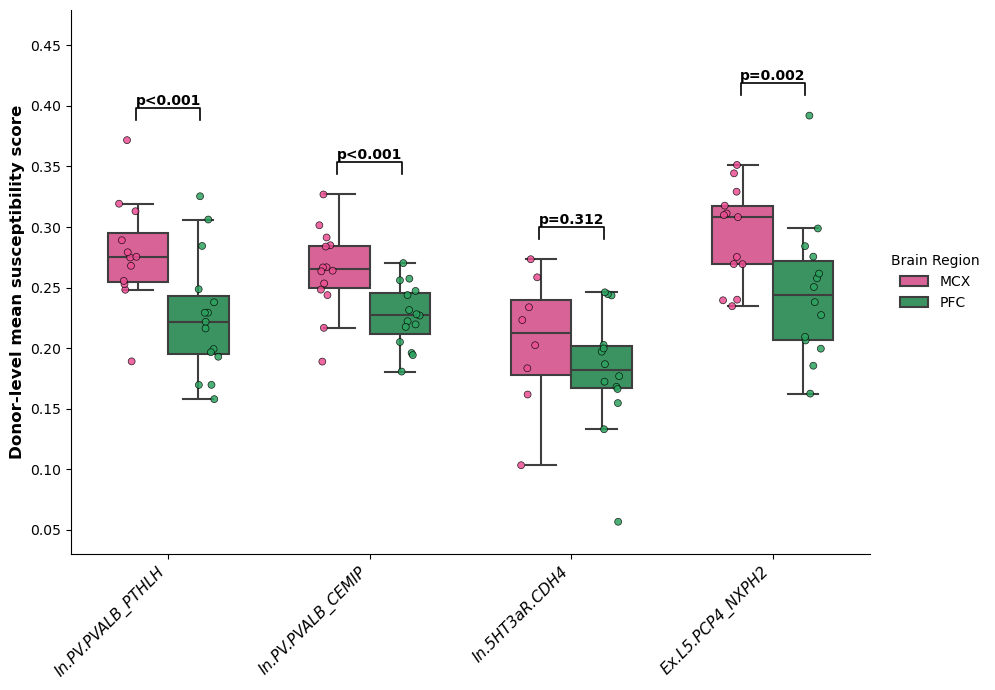

In [11]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, wilcoxon
from statsmodels.stats.multitest import multipletests
import anndata

# ==========================================
# 1. 参数设置
# ==========================================
target_genes = [
    'DCTN1', 'KIF5A', 'TNIP1', 'SS18L1', 'SPP1', 'DYNC1H1', 'STMN2',
    'FGD4', 'NEFH', 'NEK1', 'CAMTA1', 'ENAH', 'CDH22', 'CRYM',
    'CHCHD10', 'C9orf72', 'MATR3', 'HNRNPA1', 'DPP6'
]

target_subtypes = [
    'In.PV.PVALB_PTHLH',
    'In.PV.PVALB_CEMIP',
    'In.5HT3aR.CDH4',
    'Ex.L5.PCP4_NXPH2',
]

actual_subtypes_to_extract = [
    'In.PV.PVALB_PTHLH',
    'In.PV.PVALB_CEMIP',
    'In.5HT3aR.CDH4_CCK',
    'In.5HT3aR.CDH4_SCGN',
    'Ex.L5.PCP4_NXPH2'
]

cell_type_col = 'Org_celltype'
donor_col = 'Donor_ID'
disease_col = 'Group'
pn_label = 'PN'

paths = {
    "MCX": "/root/autodl-tmp/jupyter/prepare/harmony/SALS_MCX_control_concat_QC_harmony.h5ad",
    "PFC": "/root/autodl-tmp/jupyter/prepare/harmony/SALS_PFC_control_concat_QC_harmony.h5ad"
}

out_dir = "/root/autodl-tmp/jupyter/vulnerable_neurons/09_scDRS_TXD_integrated/results/ALS_RISK_gene_enrichment_merged"
os.makedirs(out_dir, exist_ok=True)

min_cells_per_donor_subtype = 5

# ==========================================
# 2. 数据加载、清洗与打分
# ==========================================
def load_and_prep(path, region):
    adata = sc.read_h5ad(path)
    adata_calc = adata.raw.to_adata() if adata.raw is not None else adata

    mask = (
        (adata_calc.obs[disease_col] == pn_label) &
        (adata_calc.obs[cell_type_col].isin(actual_subtypes_to_extract))
    )

    adata_sub = adata_calc[mask].copy()
    adata_sub.obs['Region'] = region
    return adata_sub


adata_mcx = load_and_prep(paths["MCX"], "MCX")
adata_pfc = load_and_prep(paths["PFC"], "PFC")

adata_merged = anndata.concat([adata_mcx, adata_pfc], join='inner')

adata_merged.obs[cell_type_col] = (
    adata_merged.obs[cell_type_col]
    .astype(str)
    .replace({
        'In.5HT3aR.CDH4_CCK': 'In.5HT3aR.CDH4',
        'In.5HT3aR.CDH4_SCGN': 'In.5HT3aR.CDH4'
    })
)

if donor_col not in adata_merged.obs.columns:
    print("Available obs columns:")
    print(list(adata_merged.obs.columns))
    raise ValueError(f"{donor_col} not found in adata_merged.obs")

genes_to_test = [g for g in target_genes if g in adata_merged.var_names]

print("Genes used for scoring:")
print(genes_to_test)

sc.tl.score_genes(
    adata_merged,
    gene_list=genes_to_test,
    score_name='ALS_FTD_Susceptibility_Score'
)

df_cell = adata_merged.obs[
    [donor_col, cell_type_col, 'Region', 'ALS_FTD_Susceptibility_Score']
].copy()

df_cell = df_cell.dropna(
    subset=[donor_col, cell_type_col, 'Region', 'ALS_FTD_Susceptibility_Score']
)

df_cell[cell_type_col] = (
    df_cell[cell_type_col]
    .astype(str)
    .replace({
        'In.5HT3aR.CDH4_CCK': 'In.5HT3aR.CDH4',
        'In.5HT3aR.CDH4_SCGN': 'In.5HT3aR.CDH4'
    })
)

df_cell[cell_type_col] = pd.Categorical(
    df_cell[cell_type_col],
    categories=target_subtypes,
    ordered=True
)

# ==========================================
# 3. 汇总到 donor level
# ==========================================
df_donor = (
    df_cell
    .groupby([donor_col, 'Region', cell_type_col], observed=True)
    .agg(
        mean_score=('ALS_FTD_Susceptibility_Score', 'mean'),
        median_score=('ALS_FTD_Susceptibility_Score', 'median'),
        n_cells=('ALS_FTD_Susceptibility_Score', 'size')
    )
    .reset_index()
)

df_donor = df_donor[df_donor['n_cells'] >= min_cells_per_donor_subtype].copy()

score_col = 'mean_score'

print("Donor-level summary:")
print(df_donor.head())
print(df_donor.groupby([cell_type_col, 'Region'], observed=True)[donor_col].nunique())

donor_score_fp = os.path.join(
    out_dir,
    "ALS_FTD_gene_susceptibility_score_PN_MCX_vs_PFC_donor_level.tsv"
)
df_donor.to_csv(donor_score_fp, sep='\t', index=False)
print(f"Saved donor-level scores: {donor_score_fp}")

# ==========================================
# 4. Donor-level 统计
# ==========================================
stats_records = []

for subtype in target_subtypes:
    sub_df = df_donor[df_donor[cell_type_col] == subtype].copy()

    scores_mcx = sub_df[
        sub_df['Region'] == 'MCX'
    ][[donor_col, score_col]].dropna()

    scores_pfc = sub_df[
        sub_df['Region'] == 'PFC'
    ][[donor_col, score_col]].dropna()

    n_mcx = scores_mcx.shape[0]
    n_pfc = scores_pfc.shape[0]

    paired = scores_mcx.merge(
        scores_pfc,
        on=donor_col,
        suffixes=('_MCX', '_PFC')
    )

    test_name = None
    stat = np.nan
    pval = np.nan

    if paired.shape[0] >= 3:
        test_name = 'paired Wilcoxon signed-rank'
        try:
            stat, pval = wilcoxon(
                paired[f'{score_col}_MCX'],
                paired[f'{score_col}_PFC'],
                alternative='two-sided'
            )
        except ValueError:
            pval = 1.0

    elif n_mcx >= 3 and n_pfc >= 3:
        test_name = 'Mann-Whitney U'
        stat, pval = mannwhitneyu(
            scores_mcx[score_col],
            scores_pfc[score_col],
            alternative='two-sided'
        )

    stats_records.append({
        'Subtype': subtype,
        'n_MCX_donors': n_mcx,
        'n_PFC_donors': n_pfc,
        'n_paired_donors': paired.shape[0],
        'test': test_name,
        'statistic': stat,
        'p_value': pval
    })

stats_df = pd.DataFrame(stats_records)

valid = stats_df['p_value'].notna()
stats_df['FDR'] = np.nan

if valid.sum() > 0:
    stats_df.loc[valid, 'FDR'] = multipletests(
        stats_df.loc[valid, 'p_value'],
        method='fdr_bh'
    )[1]

stats_fp = os.path.join(
    out_dir,
    "ALS_FTD_gene_susceptibility_score_PN_MCX_vs_PFC_donor_level_stats.tsv"
)
stats_df.to_csv(stats_fp, sep='\t', index=False)

print("Donor-level stats:")
print(stats_df)
print(f"Saved donor-level stats: {stats_fp}")

# ==========================================
# 5. 可视化 donor-level score
# ==========================================
fig, ax = plt.subplots(figsize=(12, 7))

palette = {
    "MCX": "#ec4f93",
    "PFC": "#2ca25f"
}

sns.boxplot(
    data=df_donor,
    x=cell_type_col,
    y=score_col,
    hue='Region',
    hue_order=['MCX', 'PFC'],
    palette=palette,
    fliersize=0,
    width=0.6,
    ax=ax,
    linewidth=1.5
)

sns.stripplot(
    data=df_donor,
    x=cell_type_col,
    y=score_col,
    hue='Region',
    hue_order=['MCX', 'PFC'],
    dodge=True,
    palette=palette,
    size=5,
    alpha=0.85,
    linewidth=0.5,
    edgecolor='black',
    ax=ax
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[:2],
    labels[:2],
    title='Brain Region',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    borderaxespad=0
)

y_min = df_donor[score_col].min()
y_max = df_donor[score_col].max()
y_range = y_max - y_min
if y_range <= 0:
    y_range = 1.0

line_h = y_range * 0.03
max_anno_y = y_max

for i, subtype in enumerate(target_subtypes):
    row = stats_df[stats_df['Subtype'] == subtype]

    if row.empty:
        continue

    pval = row['p_value'].iloc[0]

    if not np.isfinite(pval):
        continue

    sub_df = df_donor[df_donor[cell_type_col] == subtype].copy()

    if pval < 0.001:
        label = 'p<0.001'
    else:
        label = f'p={pval:.3f}'

    x1, x2 = i - 0.16, i + 0.16
    local_max = sub_df[score_col].max()
    y = local_max + y_range * 0.05

    ax.plot(
        [x1, x1, x2, x2],
        [y, y + line_h, y + line_h, y],
        lw=1.2,
        color='black'
    )

    ax.text(
        (x1 + x2) * 0.5,
        y + line_h,
        label,
        ha='center',
        va='bottom',
        color='black',
        fontweight='bold',
        fontsize=10
    )

    max_anno_y = max(max_anno_y, y + line_h)

ax.set_ylim(y_min - y_range * 0.08, max_anno_y + y_range * 0.18)

ax.set_title(
    '',
    fontsize=16,
    weight='bold',
    pad=25
)

ax.set_ylabel(
    'Donor-level mean susceptibility score',
    fontsize=12,
    weight='bold'
)

ax.set_xlabel('')

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontstyle='italic',
    fontsize=11
)

sns.despine()

plt.tight_layout(rect=[0, 0, 0.84, 1])

png_fp = os.path.join(
    out_dir,
    "ALS_FTD_gene_susceptibility_score_PN_MCX_vs_PFC_donor_level.png"
)

pdf_fp = os.path.join(
    out_dir,
    "ALS_FTD_gene_susceptibility_score_PN_MCX_vs_PFC_donor_level.pdf"
)

fig.savefig(png_fp, dpi=300, bbox_inches='tight')
fig.savefig(pdf_fp, bbox_inches='tight')

print(f"Saved PNG: {png_fp}")
print(f"Saved PDF: {pdf_fp}")

plt.show()


In [4]:
import torch

In [10]:
print(torch.ones(2,10))


tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
